In [1]:
#IMPORT LIBRARIES
import os
import numpy as np
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import shape
from collections import Counter
from rasterio.features import shapes
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import sqlite3
import seaborn as sns
from datetime import datetime
import folium
from folium.plugins import Draw

In [2]:
# DATA PREPARATION
# Load raster files and validates dimension match before stacking bands into a single file per scene
def LoadAndStack(folder_path, bands):
    band_data = []
    metadata = None
    crs_list = []
    dimension_list = []
    band_names = []
    #Loading raster files
    for band in bands:
        band_files = [f for f in os.listdir(folder_path) if band in f]
        band_file = os.path.join(folder_path, band_files[0])
        band_names.append(band_files[0])
        with rasterio.open(band_file) as src:
            # Print coordinate reference system from scene for manual review
            crs_list.append(src.crs)
            print(f"{band}: CRS = {src.crs}")
            #Print raster dimensions for manual review
            dimension_list.append((src.height, src.width))
            print(f"{band}: Dimensions = {src.height} x {src.width}")
            data = src.read(1)
            band_data.append(data)
            if metadata is None:
                metadata = src.profile
                metadata.update(count=len(bands))
    # Coordinate consistency check between bands for manual review
    unique_crs = set(crs_list)
    if len(unique_crs) != 1:
        raise ValueError(f"CRS are not equal: {unique_crs}")
    print(f"  ✅ CRS are equal: {crs_list[0]}")
    #Dimensions consistency check between bands for manual review
    unique_dims = set(dimension_list)
    if len(unique_dims) != 1:
        raise ValueError(f"Dimensions are not equal: {unique_dims}")
    print(f"  ✅ Dimensions are equal: {dimension_list[0][0]} x {dimension_list[0][1]}")
    # Stacking bands into a single raster file
    stack = np.stack(band_data, axis=0)
    return stack, metadata

# DATA PREPARATION
# Quality check of stacking process between scenes
def StackValidation(stack1, metadata1, stack2, metadata2, date1, date2):
    # Coordinate reference system consistency check for manual review
    if metadata1['crs'] != metadata2['crs']:
        raise ValueError(f"CRS don't match: {metadata1['crs']} vs {metadata2['crs']}")
    print(f"  ✅ CRS match: {metadata1['crs']}")
    # Dimensions consistency check for manual review
    if metadata1['height'] != metadata2['height'] or metadata1['width'] != metadata2['width']:
        raise ValueError(
            f"Dimensions don't match: {metadata1['height']}x{metadata1['width']} vs {metadata2['height']}x{metadata2['width']}")
    print(f"  ✅ Dimensions match: {metadata1['height']}x{metadata1['width']}")
    # Band consistency check for manual review
    if stack1.shape[0] != stack2.shape[0]:
        raise ValueError(f"Bands don't match: {stack1.shape[0]} vs {stack2.shape[0]}")
    print(f"  ✅ Bands match: {stack1.shape[0]}")
    # Format consistency check for manual review
    if stack1.dtype != stack2.dtype:
        print(f" Different Dtype: {stack1.dtype} vs {stack2.dtype}")
    print(f"  ✅ Stacks match: {date1} y {date2}")
    return True

# DATA PREPARATION
# Remove invalid pixels out of range
def MaskInvalidPixels(stack, threshold_min=0, threshold_max=10000):
    # Crear máscara combinada
    stack = stack.astype(np.float32)
    # Crear máscara combinada (todos True inicialmente)
    mask = np.ones(stack.shape[1:], dtype=bool)
    for band in range(stack.shape[0]):
        band_data = stack[band]
        mask = mask & (band_data > threshold_min) & (band_data < threshold_max)
    # Aplicar máscara a todas las bandas
    masked_stack = stack.copy()
    for band in range(stack.shape[0]):
        masked_stack[band][~mask] = np.nan
    return masked_stack, mask

# CHANGE DETECTION
# Calculates NDVI (from bands B03 and B04) and ratios
def SpectralIndex(stack):
    # Bands definition
    B02 = stack[0].astype(np.float32)  # Blue
    B03 = stack[1].astype(np.float32)  # Green
    B04 = stack[2].astype(np.float32)  # Red
    ndvi = (B03 - B04) / (B03 + B04 + 1e-10)
    B02_B03 = B02 / (B03 + 1e-10)
    B02_B04 = B02 / (B04 + 1e-10)
    B03_B04 = B03 / (B04 + 1e-10)
    B03_B02 = B03 / (B02 + 1e-10)
    B04_B02 = B04 / (B02 + 1e-10)
    B04_B03 = B04 / (B03 + 1e-10)
    stack_index = np.concatenate([stack, ndvi[np.newaxis, :, :], B02_B03[np.newaxis, :, :], B02_B04[np.newaxis, :, :], B03_B02[np.newaxis, :, :], B03_B04[np.newaxis, :, :], B04_B02[np.newaxis, :, :], B04_B03[np.newaxis, :, :]], axis=0)
    return stack_index

# CHANGE DETECTION
# Apply a normalization based on available bands for correction
def NormalizeHistogram(stack1, stack2, band_indices=[0, 1, 2]):
    stack1 = stack1.astype(np.float32)
    stack2 = stack2.astype(np.float32)
    normalized = stack2.copy()
    for band_idx in band_indices:
        # Get band values in both images
        ref_band = stack1[band_idx]
        target_band = stack2[band_idx]
        # Calculate percentiles 2 y 98 (excluding NaN)
        ref_min = np.nanpercentile(ref_band, 2)
        ref_max = np.nanpercentile(ref_band, 98)
        target_min = np.nanpercentile(target_band, 2)
        target_max = np.nanpercentile(target_band, 98)
        if target_max - target_min == 0:
            continue
        # Linear correction
        normalized_band = (target_band - target_min) / (target_max - target_min)
        normalized_band = normalized_band * (ref_max - ref_min) + ref_min
        normalized[band_idx] = normalized_band
    return normalized

# CHANGE DETECTION
# Extracts fields at given coordinates from supervised observation points.
def PointExtract(stack, points_gdf, metadata):
    coords = [(geom.x, geom.y) for geom in points_gdf.geometry]
    features = []
    for x, y in coords:
        # Transform coordinates to pixel
        col, row = ~metadata['transform'] * (x, y)
        row, col = int(round(row)), int(round(col))
        # Extracts the values of bands within the image at given points
        if 0 <= row < stack.shape[1] and 0 <= col < stack.shape[2]:
            vector = [stack[b][row, col] for b in range(stack.shape[0])]
            features.append(vector)
        else:
            features.append([np.nan] * stack.shape[0])
    # Create DataFrame output
    band_names = [f'B{b + 2}' for b in range(3)] + ['NDVI'] + ['B02/B03'] + ['B02/B04'] + ['B03/B02'] + ['B03/B04'] + ['B04/B02'] + ['B04/B03']
    df = pd.DataFrame(features, columns=band_names)
    df['label'] = points_gdf['Class'].values
    return df.dropna()

# CHANGE DETECTION
# Train a Random Forest Classification model with supervised observations to predict classes in a scene
def TrainClassifier(X, y, class_names, config):
    test_size = config['RFC_TEST_SIZE']
    n_estimators = config['RFC_N_ESTIMATORS']
    random_state = config['RFC_RANDOM_STATE']
    class_weight = config['RFC_CLASS_WEIGHT']
    # Training/Test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    # Model training
    RFC = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state, class_weight=class_weight)
    RFC.fit(X_train, y_train)
    # Model deployment
    y_pred = RFC.predict(X_test)
    print("\n Classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names))
    return RFC

# CHANGE DETECTION
# Apply the classification model to a stacked scene
def ClassifyImage(stack, RFC, metadata, class_names):
    rows, cols = stack.shape[1], stack.shape[2]
    classified = np.zeros((rows, cols), dtype=np.uint8)
    # Stack bands + NDVI for classes prediction
    features = stack.reshape(stack.shape[0], -1).T
    # Prediction across the raster
    predictions = RFC.predict(features)
    # Convert classes to index
    class_idx = {name: idx for idx, name in enumerate(class_names)}
    vectorized = np.vectorize(lambda x: class_idx.get(x, 0))
    predictions_numeric = vectorized(predictions)
    classified = predictions_numeric.reshape(rows, cols)
    return classified

#CHANGE DETECTION:
# Detect pixel changes using PCA
def ChangeDetection(stack1_index, stack2_index, config):
    # Scaling classes to index
    bands1 = stack1_index[:3]
    bands2 = stack2_index[:3]
    rows, cols = bands1.shape[1], bands1.shape[2]
    mask_valid = ~(np.isnan(bands1).any(axis=0) | np.isnan(bands2).any(axis=0))
    X1_valid = bands1[:, mask_valid].reshape(3, -1).T  # (n_valid_pixels, 3)
    X2_valid = bands2[:, mask_valid].reshape(3, -1).T
    # PCA
    pca = PCA(n_components=2)
    X1_pca = pca.fit_transform(X1_valid)
    X2_pca = pca.transform(X2_valid)
    spectral_distance = np.full((rows, cols), np.nan, dtype=np.float32)
    distances = np.sqrt(np.sum((X1_pca - X2_pca) ** 2, axis=1))
    spectral_distance[mask_valid] = distances
    threshold_percentile = config.get("SPECTRAL_CHANGE_PERCENTILE", 95)
    threshold = np.nanpercentile(spectral_distance, threshold_percentile)
    #Mapping change
    change_map = np.zeros((rows, cols), dtype=bool)
    change_map[mask_valid] = spectral_distance[mask_valid] > threshold
    print(f"  PCA: variance explained by PC1: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"  PCA: variance explained by PC2: {pca.explained_variance_ratio_[1]:.3f}")
    print(f"  Spectral change threshold (percentile {threshold_percentile}): {threshold:.4f}")
    print(f"  Pixels changed: {np.sum(change_map):,} ({np.sum(change_map)/change_map.size*100:.2f}%)")
    return change_map

# CHANGE FEATURE EXTRACTION AND STORAGE
# Save results into an array
def SaveRaster(output_path, data, meta, dtype=rasterio.float32):
    if len(data.shape) == 2:
        data = data[np.newaxis, :, :]
    out_meta = meta.copy()
    out_meta.update({'count': data.shape[0], 'dtype': dtype, 'compress': 'lzw'})
    with rasterio.open(output_path, 'w', **out_meta) as dst:
        dst.write(data)
    print(f" Saved: {output_path}")

# CHANGE FEATURE EXTRACTION AND STORAGE
# Saves binary map in polygon shapefile, including the most frequent class
def VectorizeMap(change_map, classified, metadata, config, class_names):
    min_area = config["MIN_AREA"]
    utm_epsg = config["UTM_EPSG"]
    # Creating mask
    mask = change_map == 1
    # Extracting polygons
    results_raw = []
    for polygon, value in shapes(mask.astype(np.uint8), mask=mask, transform=metadata['transform']):
        results_raw.append({'properties': {'change': 1}, 'geometry': polygon})
    # Converting into GeoDataFrame
    gdf_temp = gpd.GeoDataFrame.from_features(results_raw)
    if gdf_temp.empty:
        print(" No change detected")
        return gdf_temp
    crs_str = metadata['crs'].to_string()
    gdf_temp = gdf_temp.set_crs(crs_str, allow_override=True)
    # Extract most frequent class per polygon
    class_list = []
    transform = metadata['transform']
    height, width = classified.shape
    for geom in gdf_temp.geometry:
        mask_polygon = geometry_mask([geom], out_shape=(height, width), transform=transform, invert=True)
        class_values = classified[mask_polygon]
        if len(class_values) > 0:
            most_common_class = Counter(class_values).most_common(1)[0][0]
            class_name = class_names[most_common_class] if most_common_class < len(class_names) else "Unknown"
        else:
            class_name = "Unknown"
        class_list.append(class_name)
    # Add class into GeoDataFrame
    gdf_temp['class'] = class_list
    # Calculating area in sq meters
    gdf_proj = gdf_temp.to_crs(utm_epsg) # UTM for estimation
    gdf_temp['area_m2'] = gdf_proj.geometry.area
    gdf = gdf_temp.to_crs("EPSG:4326")  # WGS84 for storage
    # Filtering by min area
    gdf = gdf[gdf['area_m2'] >= min_area]
    print(f" Detected polygons: {len(gdf)}")
    print(f" Minimum area: {min_area} sq.m")
    print(f" Total area: {gdf['area_m2'].sum():.2f} sq.m")
    return gdf

# CHANGE FEATURE EXTRACTION AND STORAGE
# Saves polygons in a SQL query-ready database. including class information
def StoreDatabase(gdf, db_path):
    print(f" Storing in SQLite")
    # Connecting to SQLite
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    # Check if DB has class column
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='change_features'")
    table_exists = cursor.fetchone() is not None
    # Adds class column if does not exist
    if table_exists:
        cursor.execute("PRAGMA table_info(change_features)")
        columns = [col[1] for col in cursor.fetchall()]
        if 'class' not in columns:
            cursor.execute("ALTER TABLE change_features ADD COLUMN class TEXT")
        if 'geometry_wkt' not in columns:
            cursor.execute("ALTER TABLE change_features ADD COLUMN geometry_wkt TEXT")
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS change_features (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            date_before TEXT,
            date_after TEXT,
            area_m2 REAL,
            confidence REAL,
            class TEXT
            geometry_wkt TEXT
        )
    """)
    # Inserting data
    inserted = 0
    for _, row in gdf.iterrows():
        # Convert geometry to WKT
        geom_wkt = row.geometry.wkt
        area = row['area_m2']
        confidence = 0.95
        class_name = row.get('class', 'Unknown')
        cursor.execute("""
            INSERT INTO change_features
            (date_before, date_after, area_m2, confidence, class, geometry_wkt)
            VALUES (?, ?, ?, ?, ?, ?)
        """, ('2023-08-12', '2023-09-02', area, confidence, class_name, geom_wkt))
        inserted += 1
    conn.commit()
    conn.close()
    print(f"  Database stored: {db_path}")
    print(f"  Logs inserted: {len(gdf)}")

# VISUALIZATION
# Plot change binary map
def VisualizeChangeBinary(change_map, metadata, output_dir="output"):
    extent = get_image_extent(metadata)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(change_map, cmap='Reds', interpolation='none', extent=extent)
    ax.set_title("Change detection map")
    ax.set_xlabel("Longitude")
    ax.set_xlabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2000))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2000))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    cbar = fig.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_ticklabels(['No change', 'Change'])
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "binary_change_map.png"), dpi=300, bbox_inches='tight')
    plt.show()

# VISUALIZATION
# Plot classes within detected change areas on satellite image
def VisualizeChangeClasses(stack, classified, change_map, class_names, metadata, output_dir="output"):
    # Create RGB composite
    red = stack[2]
    green = stack[1]
    blue = stack[0]
    def normalize(band):
        p2, p98 = np.percentile(band[~np.isnan(band)], (2, 98))
        return np.clip((band - p2) / (p98 - p2), 0, 1)
    rgb = np.stack([normalize(red), normalize(green), normalize(blue)], axis=2)
    mask = change_map == 1
    classified_masked = np.where(mask, classified, np.nan)
    colors = ['#e50000', '#f9bc08', '#e03fd8', '#76fda8', '#056eee']
    cmap = mcolors.ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    extent = get_image_extent(metadata)
    fig, ax = plt.subplots(figsize=(12, 10))
    # Base image and overlay class map
    ax.imshow(rgb, extent=extent, alpha= 0.3)
    im = ax.imshow(classified_masked, cmap=cmap, norm=norm, extent=extent, alpha=1)
    ax.set_title("Classes in detected change areas")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useOffset=False))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2000))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2000))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2,3,4])
    cbar.set_ticklabels(class_names)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "classes_overlay_rgb.png"), dpi=300, bbox_inches='tight')
    plt.show()

# VISUALIZATION
# Return geographic limits
def get_image_extent(metadata):
    transform = metadata['transform']
    width = metadata['width']
    height = metadata['height']
    xmin = transform[2]
    ymax = transform[5]
    xmax = xmin + transform[0] * width
    ymin = ymax + transform[4] * height
    return (xmin, xmax, ymin, ymax)

# VISUALIZATION
# Create an interactive map
def CreateInteractiveMap(change_gdf, aoi_path=None, output_dir="output"):
    if change_gdf.empty:
        print(" No polygons for visualization")
        return
    # Centroid of first polygon
    center_lat = change_gdf.geometry.centroid.y.mean()
    center_lon = change_gdf.geometry.centroid.x.mean()
    # Create base map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
    # Add AOI
    if aoi_path and os.path.exists(aoi_path):
        aoi = gpd.read_file(aoi_path)
        folium.GeoJson(aoi, name="AOI", style_function=lambda x: {'color': 'blue', 'weight': 2, 'fillOpacity': 0}).add_to(m)
    # Add polygons per class
    colors = {'Terrain':'#f9bc08', 'Mine': '#e50000', 'Urban/Road': '#e03fd8', 'Vegetation': '#76fda8', 'Water': '#056eee'}
    for _, row in change_gdf.iterrows():
        color = colors.get(row.get('class', 'Unknown'), '#cccccc')
        popup = f"Área: {row['area_m2']:.2f} sq.m<br>Clase: {row.get('class', 'Unknown')}"
        folium.GeoJson(row.geometry.__geo_interface__, style_function=lambda x, color=color: {'fillColor': color, 'color': 'black', 'weight': 1, 'fillOpacity': 0.5}, popup=popup).add_to(m)
    # Save map
    output_path = os.path.join(output_dir, "change_map_interactive.html")
    m.save(output_path)
    return m

# ANALYSIS AND INTERPRETATION
# Returns change area/pixels per class as a DataFrame
def AnalyzeChangeByClass(classified, change_map, metadata, class_names, config, output_dir="output"):
    transform = metadata['transform']
    pixel_size = abs(transform[0])
    pixel_area_m2 = pixel_size ** 2
    pixel_area_km2 = pixel_area_m2 / 1e6
    mask = change_map == 1
    pixel_counts = {}
    area_km2 = {}
    # Estimate for each class
    for class_name in class_names:
        class_id = class_names.index(class_name)
        pixels_in_change = np.sum((classified == class_id) & mask)
        pixel_counts[class_name] = pixels_in_change
        area_km2[class_name] = pixels_in_change * pixel_area_km2
    # Create DataFrames
    df_pixels = pd.DataFrame(list(pixel_counts.items()), columns=['Class', 'Pixels'])
    df_areas = pd.DataFrame(list(area_km2.items()), columns=['Class', 'Area (sq.km)'])
    # Ordering
    df_areas = df_areas.sort_values('Area (sq.km)', ascending=False)
    df_pixels = df_pixels.set_index('Class').T
    # Visualization of graphs
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(df_areas['Class'], df_areas['Area (sq.km)'], color = ['#76fda8', '#e50000', '#f9bc08', '#e03fd8', '#056eee'][:len(class_names)])
    ax.set_title("Change area per class")
    ax.set_ylabel("Area (sq.km)")
    ax.set_xlabel("Class")
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "change_area_by_class.png"), dpi=300, bbox_inches='tight')
    plt.show()
    print("\n Change area per class \n")
    print(df_areas.to_string(index=False))
    print(f"\n Total change area: {df_areas['Area (sq.km)'].sum():.3f} sq.km")
    return df_areas, df_pixels

# ANALYSIS AND INTERPRETATION
# Generate a report in Markdown
def GenerateReport(change_gdf, df_areas, config, output_dir="output", report_name="report.md"):
    # Metrics for reporting
    total_area_km2 = change_gdf['area_m2'].sum() / 1e6 if not change_gdf.empty else 0
    num_polygons = len(change_gdf) if not change_gdf.empty else 0
    area_by_class = ""
    if df_areas is not None and not df_areas.empty:
        for _, row in df_areas.iterrows():
            area_by_class += f"- **{row['Class']}**: {row['Area (sq.km)']:.3f} sq.km\n"
    # Report content
    report_content = f"""# TECHNICAL ASSIGNMENT: SENTINEL-2 CHANGE ANALYSIS
## 1. Executive Summary

The following report describes the results of a land change analysis performed using two Sentinel-2 images for the mining area of Manyama, Zambia. A land change is considered to occurr when the spectral response at pixel scale was significantly different between images. This geospatial analysis also included a classification algoritm to support the interpretation of results.

| Metric | Value |
|---------|-------|
| **Image 1 date** | 2023-08-12 |
| **Image 2 date** | 2023-09-02 |
| **Total change area** | {total_area_km2:.3f} sq.km |
| **Spectral change threshold (percentile)** | {config.get('SPECTRAL_CHANGE_PERCENTILE', 95)}% |

{area_by_class if area_by_class else "No calculated"}

## 2. Methodology

###    2.1 Classification
**Model**: Random Forest Classifier (200 trees, balanced class weights)

**Training**: Supervised observation points over date 1 scene

**Classes**: {', '.join(config.get('CLASS_NAMES', ['Terrain', 'Vegetation', 'Water', 'Mine', 'Urban/Roads']))}

| Class | Description |
|---------|-------|
| **Terrain** | Bare soil due to deforestation (either mine operation and agriculture) or natural degradation |
| **Vegetation** | Forest and other densely vegetated areas |
| **Water** | Human-made and natural water bodies|
| **Mine** | Exposed subsurface or excavated materials (tailings and gangue) |
| **Urban/Roads** | Paved roads, constructions and other infrastructure footprint |

###    2.2 Change detection

**Method**: PCA (2 components) was performed using Bands + Band ratios + NDVI proxy for a total of 10 variables. PCA captures the main spectral variance, reducing noise and atmospheric effects. Euclidean distance in this reduced space highlights spectral changes between dates.

**Threshold**: Dynamic (percentile {config.get('SPECTRAL_CHANGE_PERCENTILE', 95)}%), adapting to the data distribution.

**Minimum area of polygons**: {config.get('MIN_AREA', 100)} sq.m

## 3. Results

###    3.1 Analysis and Interpretation

According to this analysis, the largest changes are observed in vegetation class. Spectra analysis can reveal vegetation changes occurring due to loss of humidity in the soil and atmosphere, and are naturally expected as seasonal changes. This might be the case for the small and disperse areas located in the southern portion of the study area. Nevertheless, the fact that the observed change areas for this class are larger and more dense adjacent to the mine northern perimeter could be an indicator of induced vegetation stress where natural landscape is more fragmented.

The second largest change areas are related to the mine operation. The main areas are observed at the southern portion where open pit is actively operated. Likewise, large changes are observed at the areas designated to store gangue as well as the inner portion of the tailing dam, where loose debris is constantly displaced and humidity is lost.

These two classes account for 70% of the total change area, approximately.

The third class belongs to Terrain, accounting around 14% of the total change area. This class reflect changes in the bare soil that could be related to loss of humidity or erosion, as well as deforested areas. Therefore, this class can indicate where land clearing happened. The dense change areas observed mainly at the borders of the mine operations, particularly at the norther portion of the mine, might reflect expansion of the mining operations; whereas the dispersed small areas at the southern portion of the study area might reflect clearing due to agricultral practices.

Lastly, change areas at Urban/Road and Water classes are similarly low (see "Change area per class" graph below), but occurring spatially different.

As urban constructions and highly compacted paved/unpaved roads are almost impermeable, changes related to humidity or other physical conditions are less expected. Uneven small hotspots are mainly observed at some areas of the active open pit and the southern urban area. The spectral response from this class can be quite similar as the response from mine class. This is particularly observed in small disperse polygons within the urban area at the sourthen portion of the study area.

In the other hand, water polygons are larger and their location is easily identified in the image. Changes related to water bodies are expected to happen as flooding areas can either reduce with evapotranspiration or increase with rainfall. Also, the organic and inorganic composition of the water can induce variability in the spectral response.

**Change map**: ![Binary change map](binary_change_map.png)

**Classification map**: ![Classification map](classes_overlay_rgb.png)

**Change area per class**: ![Total change area per class](change_area_by_class.png)

###    3.2 Generated database

**Format**: SQLite

**Table**: `change_features`

**Fields**: `id`, `date_before`, `date_after`, `area_m2`, `confidence`, `class`, `geometry_wkt`

## 4. Limitations and recommendations

### 4.1 Limitations

**Radiometric decoupling between scenes**: The composite image consist of two scenes with different optic conditions from collection. This reduces the detection capacity of slight changes (such as vegetation phenology, greeness) in one of the scenes, resulting in underestimation of the areas. In addition, this introduces noise at the edge of scenes as observed in two straight lines across the image, resulting into overestimation of the change areas.

**Classification between dates**: Random Forest model trained with starting date has some limitations when applying to date 2, mainly due to radiometric shift. This introduces classification errors that limits the capacity to determine to which class the changes happened.

**NDVI approach**: NDVI was calculated using green band as a proxy to NIR (B08), which reduces the precision of change detection specially in vegetation areas.

**Normalization based on histogram**: This normalization was applied with the goal of reducing the errors introduced due to radiometric decoupling. However, this didn't improve significantly the results.

### 4.2 Recommendations

**Advanced atmospheric/reflectance correction**: Apply corrections across the whole composite image when downloading the data. This could enhance detections that might be hidden, particularly at the right side scene.

**Improve classification algoritm**: By labeling supervised observations corresponding to the second date, the Random Forest model could be develop to detect type of changes between classes among dates.

**Estimation of spectral index**: Providing more available bands will increase the accuracy of index estimations used for both change detection and classification.

**Environmental compliance and monitoring**: Contrast the changes detected relative to the expansion of the mining operation against the environmental permitting, particularly the Environmental Impact Assessment report. For monitoring purposes, deepen the analysis based on NDVI or other index could support the interpretation and identification of change causes.

## 5. Conclusion

The analysis identified a total change area of {total_area_km2:.3f} sq.km. The largest change areas correspond to vegetation cover, possibly due to phenology, natural degradation and induced stress. The second largest change areas correspond to mining operations, particularly at the open pit where excavation occurs and within the areas designated to store gangue and tailings.
{area_by_class if area_by_class else "No change detected."}

---
*Report generated {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*
"""
    # Save report
    report_path = os.path.join(output_dir, report_name)
    with open(report_path, 'w') as f:
        f.write(report_content)
    return report_path


 
 PART 1. DATA PREPARATION 

 
 1.1 Stacking... 

 
 Image processed: data\sentinel2_20230812
B02: CRS = EPSG:32735
B02: Dimensions = 1597 x 1673
B03: CRS = EPSG:32735
B03: Dimensions = 1597 x 1673
B04: CRS = EPSG:32735
B04: Dimensions = 1597 x 1673
  ✅ CRS are equal: EPSG:32735
  ✅ Dimensions are equal: 1597 x 1673
 File saved: output\sentinel2_20230812_stack.tif

 
 Image processed: data\sentinel2_20230902
B02: CRS = EPSG:32735
B02: Dimensions = 1597 x 1673
B03: CRS = EPSG:32735
B03: Dimensions = 1597 x 1673
B04: CRS = EPSG:32735
B04: Dimensions = 1597 x 1673
  ✅ CRS are equal: EPSG:32735
  ✅ Dimensions are equal: 1597 x 1673
 File saved: output\sentinel2_20230902_stack.tif


--------------------------------------------------

 1.2 Stacking control check...

  ✅ CRS match: EPSG:32735
  ✅ Dimensions match: 1597x1673
  ✅ Bands match: 3
  ✅ Stacks match: sentinel2_20230812 y sentinel2_20230902
Keys in metadata directory: dict_keys(['sentinel2_20230812', 'sentinel2_20230902'])
---------

C:\Users\gsanson\AppData\Local\mini_conda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


 
 PART 3. CHANGE FEATURE EXTRACTION AND STORAGE 


 3.1 Saving binary change map...
 Detected polygons: 14502
 Minimum area: 100 sq.m
 Total area: 13228600.00 sq.m
 Storing in SQLite
  Database stored: output\change_analysis.db
  Logs inserted: 14502
 Saved: output\change_map.tif
--------------------------------------------------

 3.2 Saving classification map...
 Saved: output\classification_map.tif
--------------------------------------------------

 3.3 Storing database...
 Storing in SQLite
  Database stored: output\change_analysis.db
  Logs inserted: 14502
 
 PART 4. VISUALIZATION 


 4.1 Binary change map


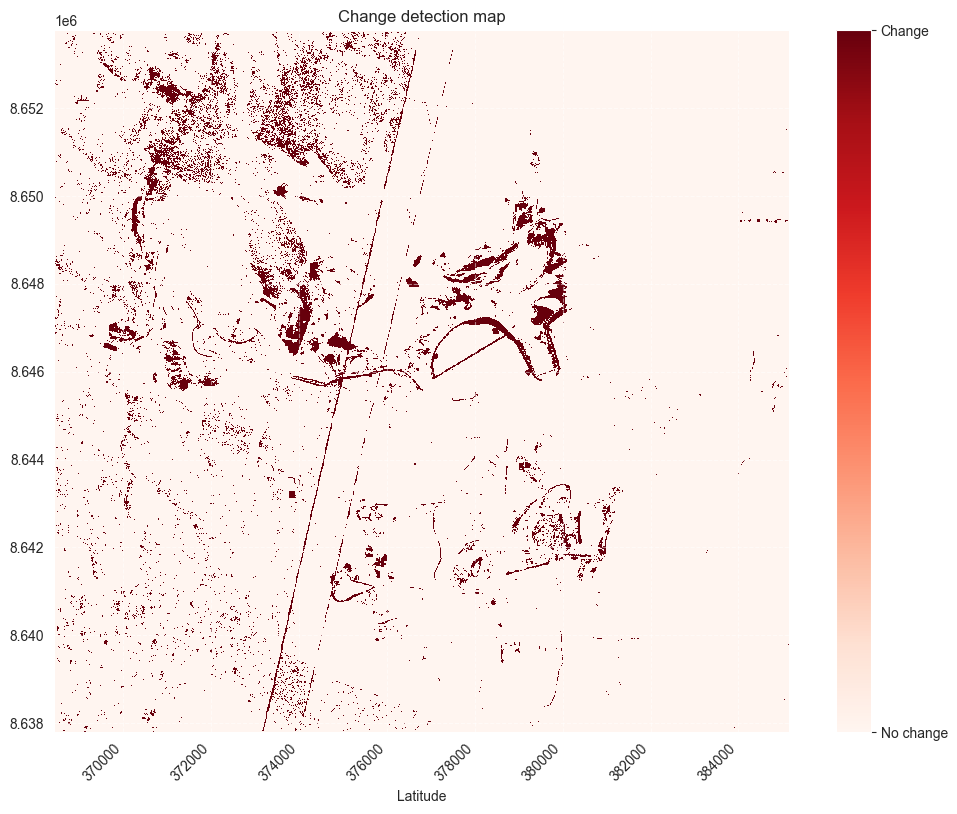


 4.2 Classification map


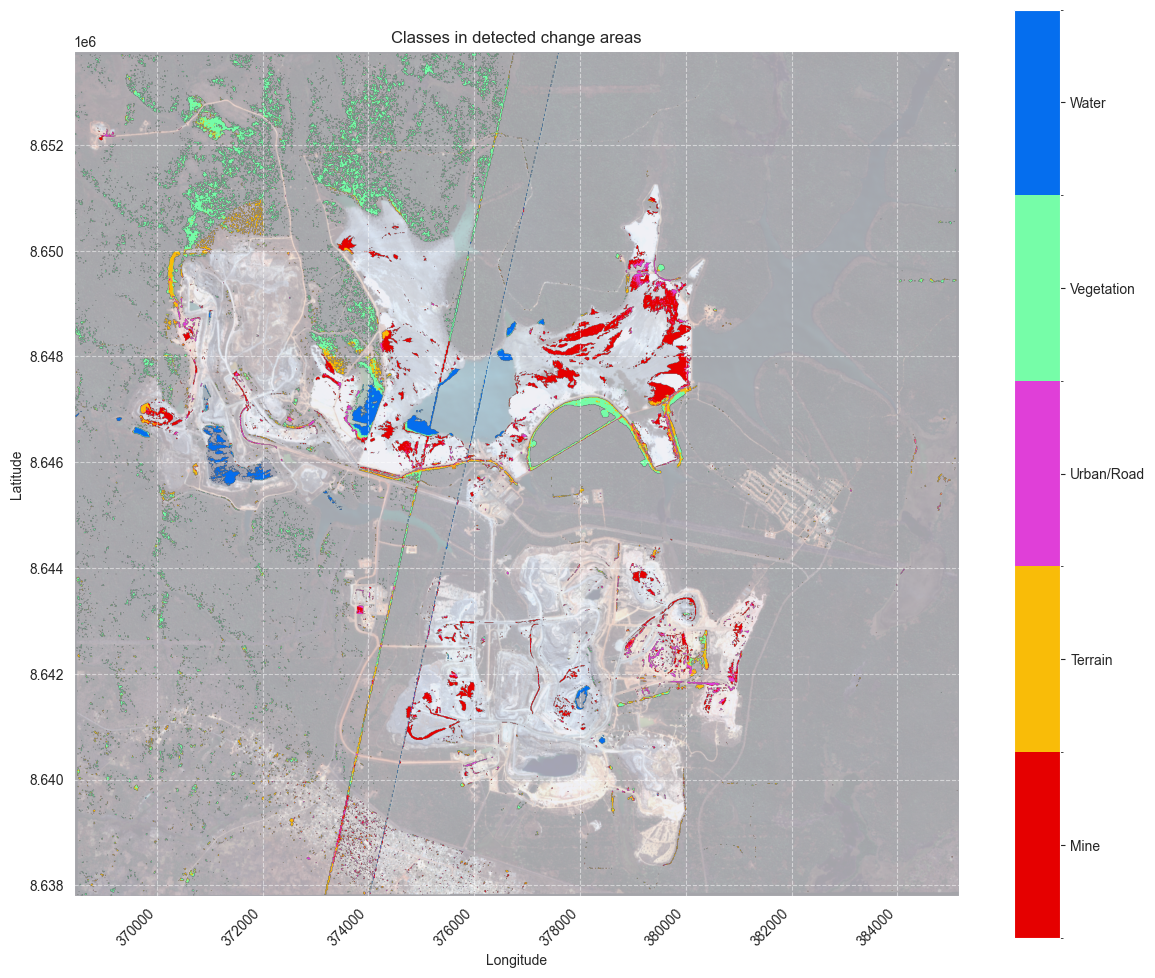


 4.3 Interactive map (Folium)


C:\Users\gsanson\AppData\Local\Temp\ipykernel_25052\1503166427.py:381: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = change_gdf.geometry.centroid.y.mean()
C:\Users\gsanson\AppData\Local\Temp\ipykernel_25052\1503166427.py:382: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = change_gdf.geometry.centroid.x.mean()


 Open 'change_map_interactive.html' in browser
 
 PART 5. ANALYSIS AND INTERPRETATION 


 5.1 Analyzing change by class...



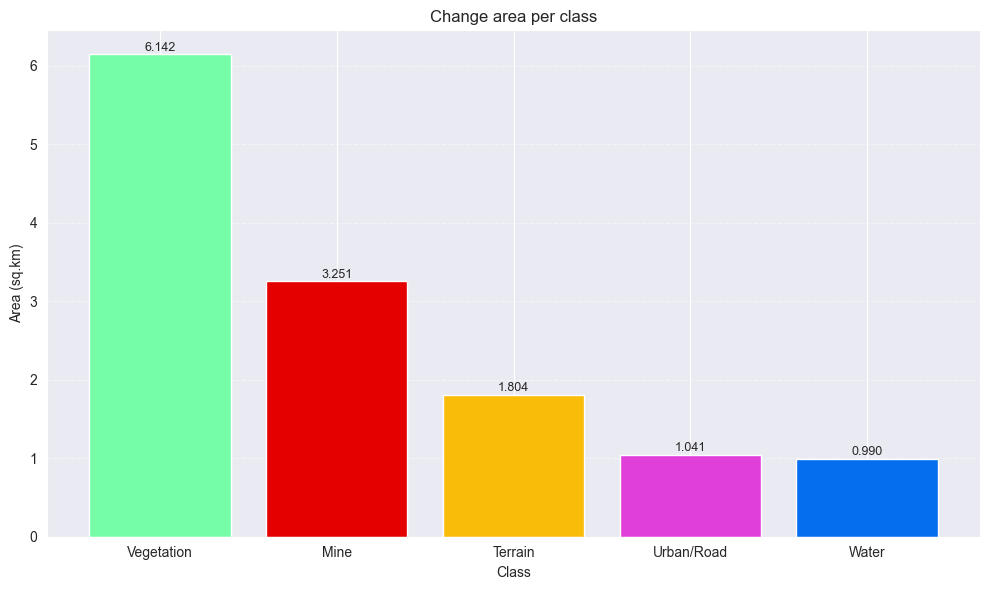


 Change area per class 

     Class  Area (sq.km)
Vegetation        6.1423
      Mine        3.2514
   Terrain        1.8045
Urban/Road        1.0407
     Water        0.9897

 Total change area: 13.229 sq.km
 Report finished: output\report.md


In [3]:
# TECHNICAL ASSIGNMENT
if __name__ == "__main__":
    # PART 0. WORKSPACE CONFIGURATION
    DATA_DIR = "data"
    FOLDERS = ["sentinel2_20230812","sentinel2_20230902"]
    BANDS = ["B02","B03","B04"]
    OUTPUT_DIR = "output"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    DB_PATH = os.path.join(OUTPUT_DIR, "change_analysis.db")
    REPORT_PATH = os.path.join(OUTPUT_DIR, "report.md")
    POINTS_FILE = "Points.geojson"
    stack_dir = {}
    metadata_dir = {}
    AOI_PATH = "aoi.geojson"
    CONFIG = {
    "DATA_DIR": "data",
    "OUTPUT_DIR": "output",
    "POINTS_FILE": "Points.geojson",
    "RFC_N_ESTIMATORS": 200,
    "RFC_RANDOM_STATE": 42,
    "RFC_CLASS_WEIGHT": "balanced",
    "RFC_TEST_SIZE": 0.2,
    "MIN_AREA": 100,
    "UTM_EPSG": "EPSG:32735",
    "FIGURE_DPI": 300,
    "SPECTRAL_CHANGE_PERCENTILE": 95,
    }

    # PART 1. DATA PREPARATION
    print("="*50)
    print(" \n PART 1. DATA PREPARATION \n")
    print("="*50)
    # 1.1 Load and stacks bands in a single array per scene
    print(" \n 1.1 Stacking... \n")
    for folder in FOLDERS:
        folder_path = os.path.join(DATA_DIR, folder)
        print(f" \n Image processed: {folder_path}")
        try:
            stack, metadata = LoadAndStack(folder_path, BANDS)
            stack_dir[folder] = stack
            metadata_dir[folder] = metadata
            output_file = os.path.join(OUTPUT_DIR, f"{folder}_stack.tif")
            with rasterio.open(output_file, 'w', **metadata) as dst:
                dst.write(stack)
            print(f" File saved: {output_file}\n")
        except Exception as e:
            print(f" ERROR: {e}\n")
    # 1.2 Stacking control check
    if len(stack_dir) == 2:
        date1, date2 = FOLDERS[0], FOLDERS[1]
        print("\n" + "-"*50)
        print("\n 1.2 Stacking control check...\n")
        StackValidation(stack_dir[date1], metadata_dir[date1], stack_dir[date2], metadata_dir[date2], date1, date2)
        print("Keys in metadata directory:", metadata_dir.keys())
        print("-"*50)

    #1.3 Apply border mask, invalid values removal, and histogram normalization between scenes
    print("\n 1.3 Filtering and normalization...\n")
    stack1_masked, mask1 = MaskInvalidPixels(stack_dir[date1])
    stack2_masked, mask2 = MaskInvalidPixels(stack_dir[date2])
    stack2_normalized = NormalizeHistogram(stack1_masked, stack2_masked, band_indices=[0, 1, 2])
    print(" Corrections applied \n")

    # PART 2. CHANGE DETECTION
    print("="*50)
    print(" \n PART 2. CHANGE DETECTION \n")
    print("="*50)
    # 2.1 Adding spectral index (NDVI and band ratios) to stack
    print(" \n 2.1 Adding spectral index...\n")
    stack1_index = SpectralIndex(stack1_masked)
    stack2_index_raw = SpectralIndex(stack2_normalized)
    # 2.2 Initial quantitative detection
    print("\n 2.2 Detecting change...\n")
    change_map = ChangeDetection(stack1_index, stack2_index_raw, CONFIG)
    # 2.3 Loading supervised observations from date 1
    print(f" \n 2.3 Loading supervised observation points: {POINTS_FILE}...")
    points_gdf = gpd.read_file(POINTS_FILE)
    class_names = sorted(points_gdf['Class'].unique())
    print(f" Classes: {class_names}")
    print(f" Distribution:\n{points_gdf['Class'].value_counts()}")
    # 2.4 Building training dataset
    print("\n 2.4 Preparing training dataset...\n")
    df = PointExtract(stack1_index, points_gdf, metadata_dir[date1])
    X = df.drop('label', axis=1)
    y = df['label']
    print(f" Total valid observations: {len(X)}")
    print(f" Independent variables: {X.shape[1]}")
    # 2.5 Training classifier with date 1 data
    print("\n 2.5 Training model...\n")
    RFC = TrainClassifier(X, y, class_names, CONFIG)
    # 2.6 Image classification using Random Forest
    print("\n 2.6 Classifying...\n")
    classified = ClassifyImage(stack1_index, RFC, metadata_dir[date1], class_names)

    # PART 3. CHANGE FEATURE EXTRACTION AND STORAGE
    print("="*50)
    print(" \n PART 3. CHANGE FEATURE EXTRACTION AND STORAGE \n")
    print("="*50)
    # 3.1 Saving binary map
    print("\n 3.1 Saving binary change map...")
    change_gdf = VectorizeMap(change_map, classified, metadata_dir[date1], CONFIG, class_names)
    if not change_gdf.empty:
        StoreDatabase(change_gdf, DB_PATH)
    else:
        print(" No changes mapped")
    SaveRaster(os.path.join(OUTPUT_DIR, "change_map.tif"), change_map.astype(np.uint8), metadata_dir[date1], dtype = rasterio.uint8)
    print("-"*50)
    # 3.2 Saving classification map
    print("\n 3.2 Saving classification map...")
    SaveRaster(os.path.join(OUTPUT_DIR, "classification_map.tif"), classified, metadata_dir[date1], dtype=rasterio.uint8)
    print("-"*50)
    # 3.3 SQLITE storage
    print("\n 3.3 Storing database...")
    DB_PATH = os.path.join(OUTPUT_DIR, "change_analysis.db")
    if not change_gdf.empty:
        StoreDatabase(change_gdf, DB_PATH)
    else:
        print(" No change detected")

    # PART 4. VISUALIZATION
    print("="*50)
    print(" \n PART 4. VISUALIZATION \n")
    print("="*50)
    # 4.1 Plotting maps
    print("\n 4.1 Binary change map")
    VisualizeChangeBinary(change_map, metadata_dir[date1], OUTPUT_DIR)
    print("\n 4.2 Classification map")
    VisualizeChangeClasses(stack_dir[date1], classified, change_map, class_names, metadata_dir[date1], OUTPUT_DIR)
    print("\n 4.3 Interactive map (Folium)")
    CreateInteractiveMap(change_gdf, AOI_PATH, OUTPUT_DIR)
    print(" Open 'change_map_interactive.html' in browser")

    # PART 5. ANALYSIS AND INTERPRETATION
    print("="*50)
    print(" \n PART 5. ANALYSIS AND INTERPRETATION \n")
    print("="*50)
    # 5.1 Change area analysis
    print("\n 5.1 Analyzing change by class...\n")
    df_areas, df_pixels = AnalyzeChangeByClass(classified, change_map, metadata_dir[date1], class_names, CONFIG, OUTPUT_DIR)
    report_path = GenerateReport(change_gdf, df_areas, CONFIG, OUTPUT_DIR, report_name="report.md")
    print(f" Report finished: {report_path}")
